# Lab 6: Binary Classification using Machine Learning and Artificial Neural Networks

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix, 
    accuracy_score, 
    precision_score,
    recall_score, 
    f1_score, 
    roc_auc_score,
    roc_curve, 
    classification_report
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

## Exercise 1: Data Understanding and Preprocessing

### 1.1 Load Dataset and Display Basic Info

In [2]:
df = pd.read_csv('datasets/UCI_Credit_Card.csv')
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [4]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


### 1.2 Handle Missing Values and Duplicates

In [5]:
df.isnull().sum(), df.duplicated().sum()

(ID                            0
 LIMIT_BAL                     0
 SEX                           0
 EDUCATION                     0
 MARRIAGE                      0
 AGE                           0
 PAY_0                         0
 PAY_2                         0
 PAY_3                         0
 PAY_4                         0
 PAY_5                         0
 PAY_6                         0
 BILL_AMT1                     0
 BILL_AMT2                     0
 BILL_AMT3                     0
 BILL_AMT4                     0
 BILL_AMT5                     0
 BILL_AMT6                     0
 PAY_AMT1                      0
 PAY_AMT2                      0
 PAY_AMT3                      0
 PAY_AMT4                      0
 PAY_AMT5                      0
 PAY_AMT6                      0
 default.payment.next.month    0
 dtype: int64,
 np.int64(0))

### 1.3 Encode Categorical Columns

In [6]:
# SEX, EDUCATION, MARRIAGE are already numeric codes in this dataset.
cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype='int')

df.head()

,ID,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,...,SEX_2,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,EDUCATION_5,EDUCATION_6,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3
0,1,20000.0,24,2,2,-1,-1,-2,-2,3913.0,...,1,0,1,0,0,0,0,1,0,0
1,2,120000.0,26,-1,2,0,0,0,2,2682.0,...,1,0,1,0,0,0,0,0,1,0
2,3,90000.0,34,0,0,0,0,0,0,29239.0,...,1,0,1,0,0,0,0,0,1,0
3,4,50000.0,37,0,0,0,0,0,0,46990.0,...,1,0,1,0,0,0,0,1,0,0
4,5,50000.0,57,-1,0,-1,0,0,0,8617.0,...,0,0,1,0,0,0,0,1,0,0


### 1.4 Define Features and Target, Normalize, and Split

In [7]:
# Drop ID column if present
df.drop('ID', axis=1, inplace=True)

X = df.drop('default.payment.next.month', axis=1)
y = df['default.payment.next.month']

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y
)

X_train.shape, X_test.shape, y.value_counts()

((24000, 30),
 (6000, 30),
 default.payment.next.month
 0    23364
 1     6636
 Name: count, dtype: int64)

## Exercise 2: Machine Learning Model Training and Evaluation

### Helper Function: Evaluate Model

In [8]:
results = {}

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, has_proba=True):

    model.fit(X_tr, y_tr)

    # ===== TRAIN PREDICTIONS =====
    y_pred_train = model.predict(X_tr)
    y_prob_train = (
        model.predict_proba(X_tr)[:, 1]
        if has_proba else model.decision_function(X_tr)
    )

    # ===== TEST PREDICTIONS =====
    y_pred_test = model.predict(X_te)
    y_prob_test = (
        model.predict_proba(X_te)[:, 1]
        if has_proba else model.decision_function(X_te)
    )

    # ===== TRAIN METRICS =====
    train_metrics = {
        'Accuracy': accuracy_score(y_tr, y_pred_train),
        'Precision': precision_score(y_tr, y_pred_train),
        'Recall': recall_score(y_tr, y_pred_train),
        'F1-Score': f1_score(y_tr, y_pred_train),
        'ROC AUC': roc_auc_score(y_tr, y_prob_train)
    }

    # ===== TEST METRICS =====
    test_metrics = {
        'Accuracy': accuracy_score(y_te, y_pred_test),
        'Precision': precision_score(y_te, y_pred_test),
        'Recall': recall_score(y_te, y_pred_test),
        'F1-Score': f1_score(y_te, y_pred_test),
        'ROC AUC': roc_auc_score(y_te, y_prob_test)
    }

    # Store everything
    results[name] = {
        'Train': train_metrics,
        'Test': test_metrics
    }

    # ================= PRINT SECTION =================
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")

    # Confusion Matrix (Test)
    print("\nConfusion Matrix (Test):")
    cm = confusion_matrix(y_te, y_pred_test)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    print("\nClassification Report (Test):")
    print(classification_report(y_te, y_pred_test))

    # ROC Curve (Test)
    fpr, tpr, _ = roc_curve(y_te, y_prob_test)
    plt.figure()
    plt.plot(fpr, tpr, label=f'{name} (AUC = {test_metrics["ROC AUC"]:.2f})')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {name}')
    plt.legend()
    plt.grid()
    plt.show()

    return model

### 2.1 Logistic Regression


Model: Logistic Regression

Confusion Matrix (Test):


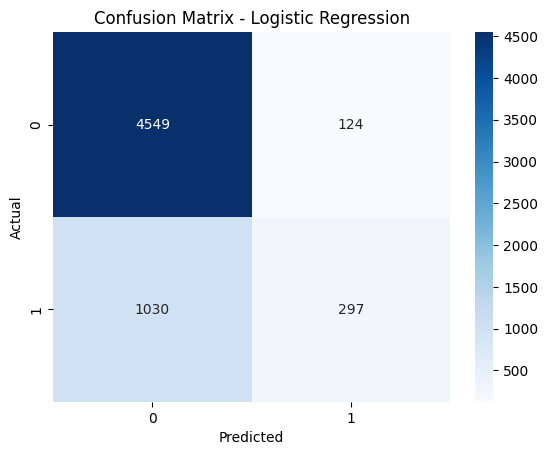


Classification Report (Test):
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.71      0.22      0.34      1327

    accuracy                           0.81      6000
   macro avg       0.76      0.60      0.61      6000
weighted avg       0.79      0.81      0.77      6000



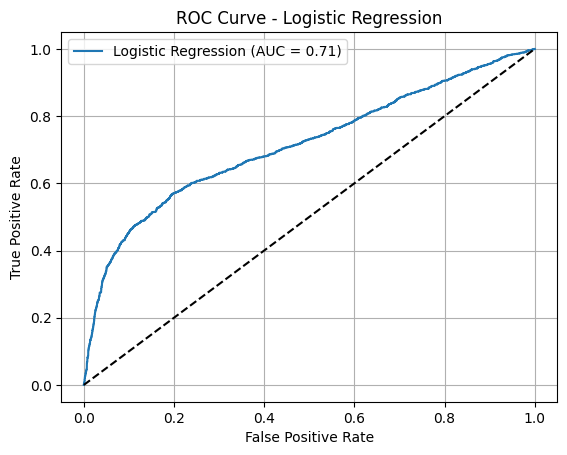

In [9]:
lr = LogisticRegression()
lr = evaluate_model('Logistic Regression', lr, X_train, X_test, y_train, y_test)

### 2.2 K-Nearest Neighbors (with Elbow Method)

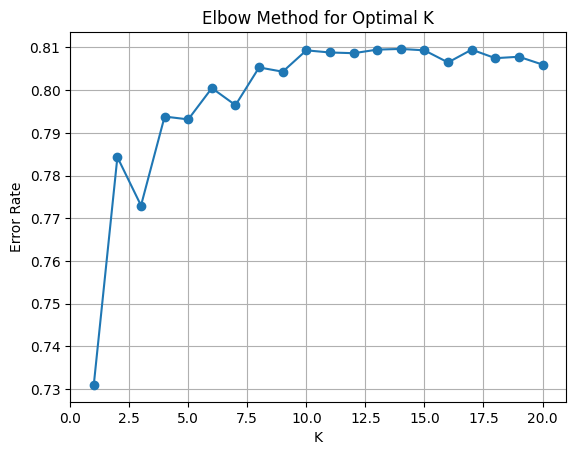

In [10]:
# Elbow method to find optimal K
k_range = range(1, 21)
k_acc = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    k_acc.append(accuracy_score(y_test, knn.predict(X_test)))

plt.plot(k_range, k_acc, marker='o')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.title('Elbow Method for Optimal K')
plt.xlim(0,21)
plt.grid()
plt.show()


Model: KNN

Confusion Matrix (Test):


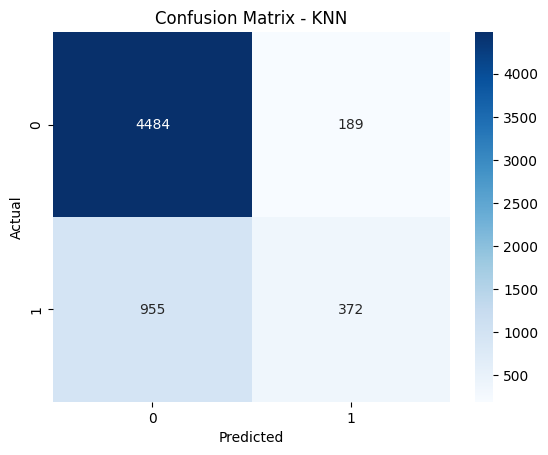


Classification Report (Test):
              precision    recall  f1-score   support

           0       0.82      0.96      0.89      4673
           1       0.66      0.28      0.39      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.62      0.64      6000
weighted avg       0.79      0.81      0.78      6000



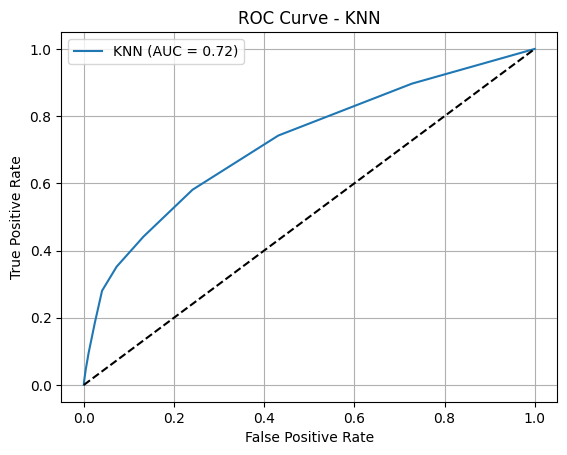

In [11]:
knn = KNeighborsClassifier(n_neighbors=10)
knn = evaluate_model('KNN', knn, X_train, X_test, y_train, y_test)

### 2.3 Decision Tree Classifier


Model: Decision Tree

Confusion Matrix (Test):


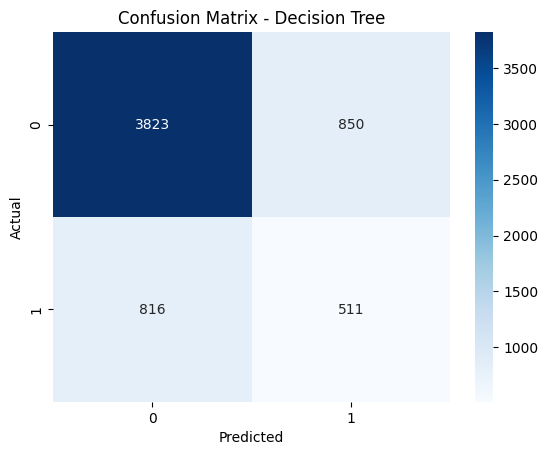


Classification Report (Test):
              precision    recall  f1-score   support

           0       0.82      0.82      0.82      4673
           1       0.38      0.39      0.38      1327

    accuracy                           0.72      6000
   macro avg       0.60      0.60      0.60      6000
weighted avg       0.72      0.72      0.72      6000



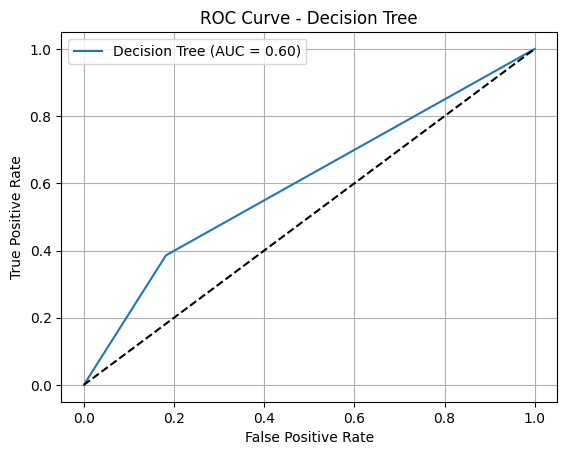

In [12]:
dt = DecisionTreeClassifier()
dt = evaluate_model('Decision Tree', dt, X_train, X_test, y_train, y_test)

### 2.4 Random Forest Classifier


Model: Random Forest

Confusion Matrix (Test):


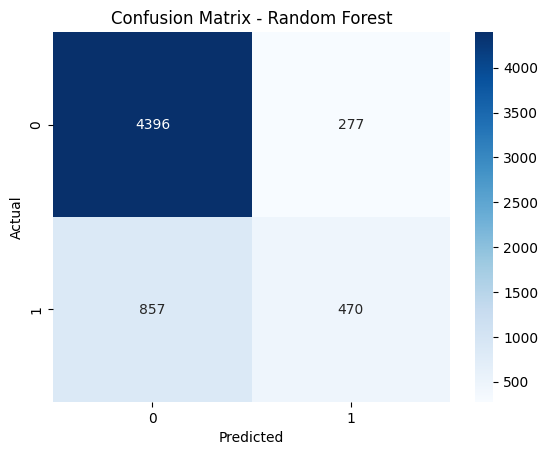


Classification Report (Test):
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.63      0.35      0.45      1327

    accuracy                           0.81      6000
   macro avg       0.73      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000



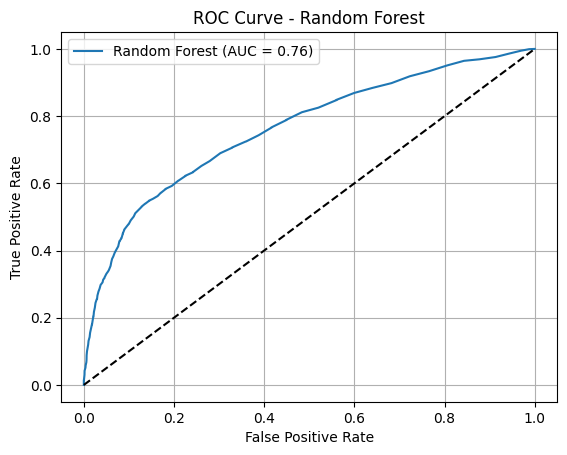

In [13]:
rf = RandomForestClassifier()
rf = evaluate_model('Random Forest', rf, X_train, X_test, y_train, y_test)

### 2.5 Support Vector Machine (SVM)


Model: SVM

Confusion Matrix (Test):


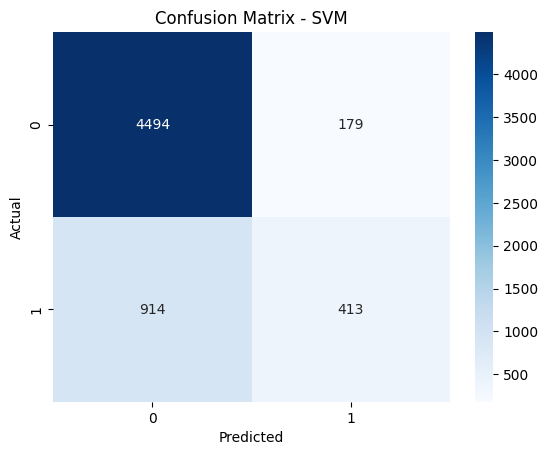


Classification Report (Test):
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      4673
           1       0.70      0.31      0.43      1327

    accuracy                           0.82      6000
   macro avg       0.76      0.64      0.66      6000
weighted avg       0.80      0.82      0.79      6000



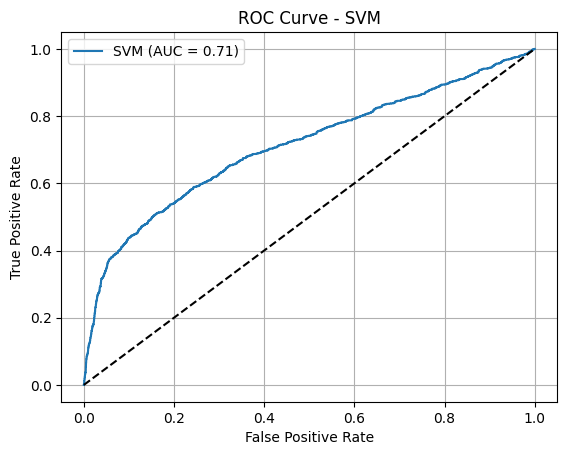

In [14]:
svm = SVC(kernel='rbf')
svm = evaluate_model('SVM', svm, X_train, X_test, y_train, y_test, has_proba=False)

## Exercise 3: Deep Learning Model – Artificial Neural Network (ANN)

### 3.1 Build and Compile the ANN

In [15]:
ann = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

ann.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

D:\python\python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 3.2 Train the ANN

In [16]:
history = ann.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=0
)

### 3.3 Plot Training Accuracy and Loss Curves

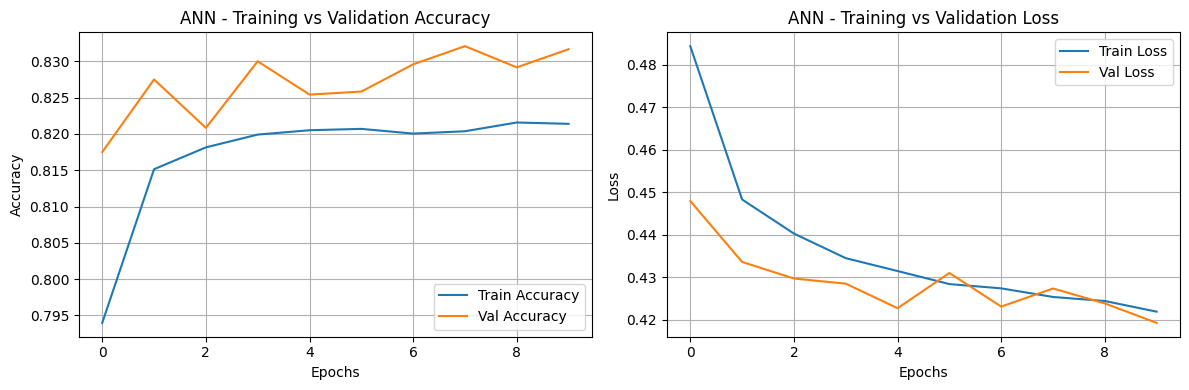

In [17]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('ANN - Training vs Validation Accuracy')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('ANN - Training vs Validation Loss')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

### 3.4 Evaluate ANN on Test Set

In [18]:
# ===== TRAIN PREDICTIONS =====
y_prob_train_ann = ann.predict(X_train, verbose=0).flatten()
y_pred_train_ann = (y_prob_train_ann >= 0.5).astype(int)

# ===== TEST PREDICTIONS =====
y_prob_test_ann = ann.predict(X_test, verbose=0).flatten()
y_pred_test_ann = (y_prob_test_ann >= 0.5).astype(int)

# ===== TRAIN METRICS =====
train_metrics_ann = {
    'Accuracy': accuracy_score(y_train, y_pred_train_ann),
    'Precision': precision_score(y_train, y_pred_train_ann),
    'Recall': recall_score(y_train, y_pred_train_ann),
    'F1-Score': f1_score(y_train, y_pred_train_ann),
    'ROC AUC': roc_auc_score(y_train, y_prob_train_ann)
}

# ===== TEST METRICS =====
test_metrics_ann = {
    'Accuracy': accuracy_score(y_test, y_pred_test_ann),
    'Precision': precision_score(y_test, y_pred_test_ann),
    'Recall': recall_score(y_test, y_pred_test_ann),
    'F1-Score': f1_score(y_test, y_pred_test_ann),
    'ROC AUC': roc_auc_score(y_test, y_prob_test_ann)
}

# Store properly
results['ANN'] = {
    'Train': train_metrics_ann,
    'Test': test_metrics_ann
}

ANN Confusion Matrix (Test):


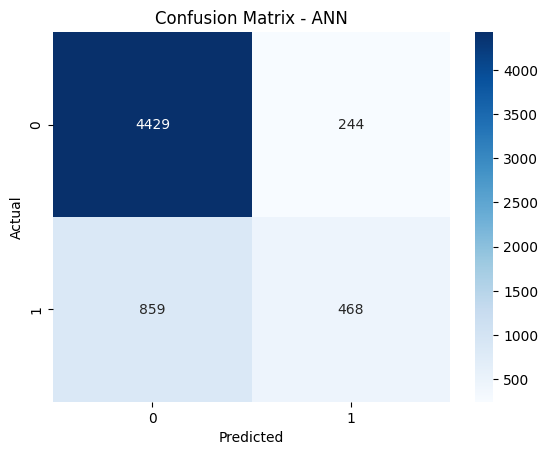


ANN Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.35      0.46      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.67      6000
weighted avg       0.80      0.82      0.79      6000



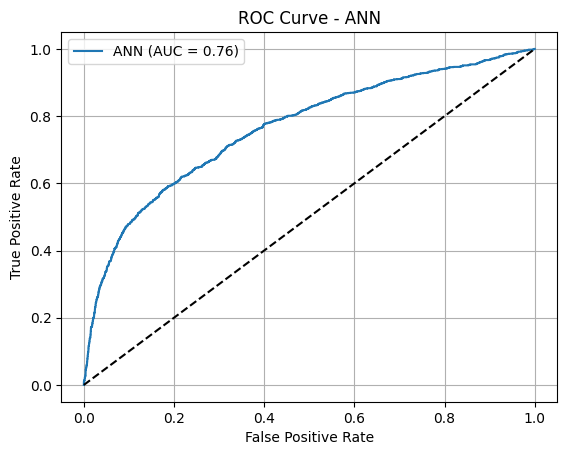

In [19]:
print("ANN Confusion Matrix (Test):")
cm_ann = confusion_matrix(y_test, y_pred_test_ann)

sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - ANN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nANN Classification Report:")
print(classification_report(y_test, y_pred_test_ann))

fpr_ann, tpr_ann, _ = roc_curve(y_test, y_prob_test_ann)

plt.plot(fpr_ann, tpr_ann, label=f'ANN (AUC = {test_metrics_ann["ROC AUC"]:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - ANN')
plt.legend()
plt.grid()
plt.show()

## Exercise 4: Model Comparison

In [20]:
comparison_df_train = pd.DataFrame({
    model: results[model]['Train']
    for model in results
}).T
comparison_df_test = pd.DataFrame({
    model: results[model]['Test']
    for model in results
}).T

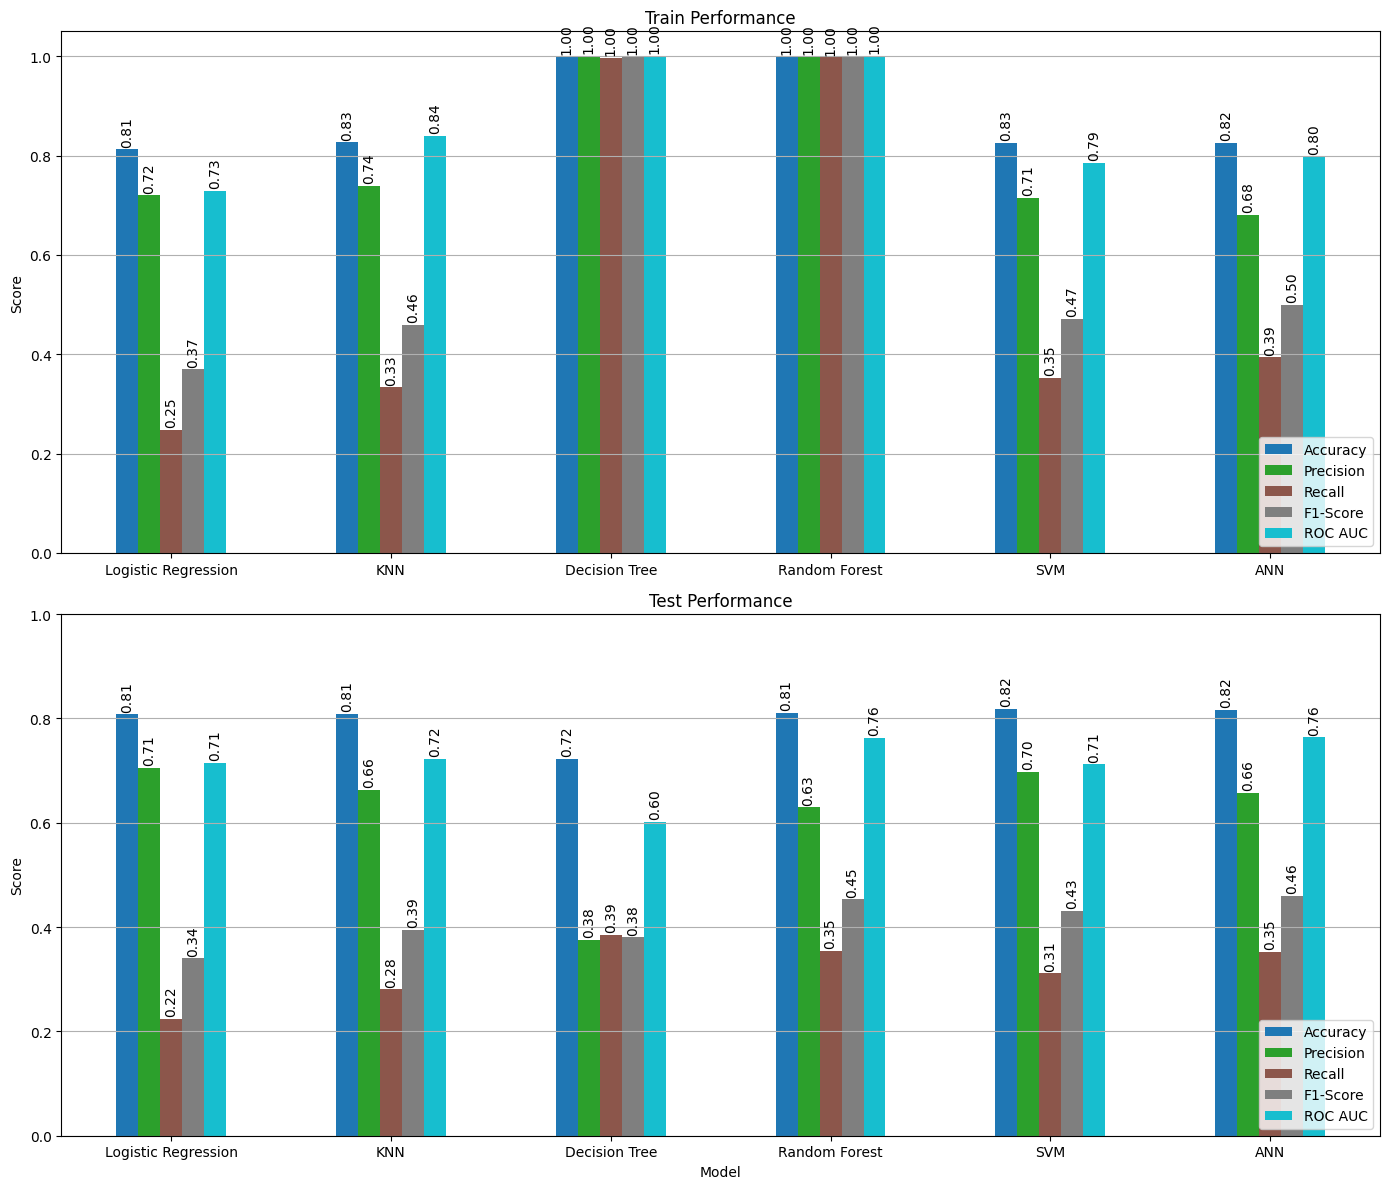

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# ===== TRAIN PLOT =====
ax1 = comparison_df_train.plot(
    kind='bar',
    ax=axes[0],
    colormap='tab10'
)

for container in ax1.containers:
    ax1.bar_label(container, fmt='%.2f', padding=2, rotation=90)

ax1.set_title('Train Performance')
ax1.set_xlabel('')
ax1.set_ylabel('Score')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
ax1.grid(axis='y')
ax1.legend(loc='lower right')

# ===== TEST PLOT =====
ax2 = comparison_df_test.plot(
    kind='bar',
    ax=axes[1],
    colormap='tab10'
)

for container in ax2.containers:
    ax2.bar_label(container, fmt='%.2f', padding=2, rotation=90)

ax2.set_title('Test Performance')
ax2.set_ylim(0,1)
ax2.set_xlabel('Model')
ax2.set_ylabel('Score')
ax2.grid(axis='y')
ax2.legend(loc='lower right')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

## Exercise 5: Analysis (Critical Thinking)

**Q1. Which model achieved the best performance? Justify using metrics.**

Based on the test set results, the Random Forest achieved the best overall performance. It had one of the highest accuracy scores (around 0.82), the highest F1-score (around 0.46), and the highest ROC AUC (around 0.77). Since this is an imbalanced dataset, metrics like F1-score and ROC AUC are more important than accuracy alone. Random Forest provided the best balance between precision and recall, making it the strongest overall model.


**Q2. Did ANN outperform traditional ML models? Why or why not?**

The ANN performed competitively but did not outperform the best traditional ML model. Its accuracy and ROC AUC were slightly lower than Random Forest, and its recall was also lower. This is because tabular financial datasets like this one often work better with tree-based models, which handle structured data and feature interactions very effectively. Neural networks typically perform better on large-scale or unstructured data such as images or text.


**Q3. Compare the training time and complexity of ANN vs ML models.**

ANNs generally require more computational resources and training time compared to traditional ML models like Logistic Regression or Decision Trees. They involve multiple layers, backpropagation, and iterative optimization across many epochs. In contrast, models like Logistic Regression and Random Forest train faster and are simpler to tune. ANN also has more hyperparameters, making it more complex to design and optimize.


**Q4. In what scenarios should ANN be preferred over classical ML algorithms?**

ANN should be preferred when dealing with large datasets, complex nonlinear relationships, or unstructured data such as images, text, or audio. They are especially useful when feature engineering is difficult and when patterns are highly complex. For structured tabular data with moderate size, classical ML models like Random Forest or Gradient Boosting are often more effective.


**Q5. Which model would you recommend for credit default prediction and why?**

For credit default prediction in this dataset, I would recommend Random Forest. It achieved the best balance between accuracy, F1-score, and ROC AUC, and it generalizes well without severe overfitting on the test data. It is also easier to interpret and tune compared to ANN, making it more practical for financial risk modeling.

## Knowledge Check Questions

**Q1. Why is Recall important in a credit default scenario?**

Recall is important because it measures how well the model identifies actual defaulters. In a credit default scenario, missing a defaulter (false negative) can lead to financial loss for the bank. A high recall means the model correctly detects most of the risky customers, which reduces the chances of approving loans to people who are likely to default.


**Q2. What is the ROC curve and what does AUC signify?**

The ROC (Receiver Operating Characteristic) curve shows the relationship between the True Positive Rate (Recall) and the False Positive Rate at different classification thresholds. It helps evaluate how well a model separates the two classes. The AUC (Area Under the Curve) represents the model’s overall ability to distinguish between classes. A higher AUC (closer to 1) indicates better classification performance, while 0.5 means the model performs like random guessing.


**Q3. Why is Sigmoid used in the output layer for binary classification?**

Sigmoid is used because it converts the output into a value between 0 and 1, which can be interpreted as a probability. In binary classification, this probability represents the likelihood that a sample belongs to the positive class (e.g., default = 1). A threshold (usually 0.5) is then used to decide the final class label.

**Q4. What advantage does ANN provide over traditional ML algorithms?**

ANNs can model complex nonlinear relationships between features and automatically learn interactions between variables. They are powerful when dealing with large datasets or highly complex patterns. Unlike some traditional ML models, neural networks can learn deep feature representations without heavy manual feature engineering.


**Q5. Why is feature scaling important for neural networks?**

Feature scaling is important because neural networks use gradient-based optimization. If features have very different ranges (for example, one feature in thousands and another in decimals), training becomes unstable and slow. Scaling ensures that all features contribute equally during learning and helps the model converge faster and more efficiently.

**Q6. How does a confusion matrix help evaluate classification models?**

A confusion matrix shows the number of True Positives, True Negatives, False Positives, and False Negatives. It helps understand not just overall accuracy, but the types of errors the model makes. From the confusion matrix, we can calculate important metrics like precision, recall, and F1-score, which are especially important in imbalanced classification problems like credit default prediction.